# Does `greedy_merit` Ensemble Actually Need Multiple Models?

**Question:** With `ensemble_agg = greedy_merit`, the ensemble picks the best member per sample.
If the **same** model always wins, we could just use that single model. If **different** models
win for different instances, the ensemble adds value.

**Test:**
1. Load ensemble members individually
2. For each test instance, compute member-level merits *after* post-processing
3. Record which member is best per instance
4. Analyse: is a single model dominant, or does selection vary?

In [78]:
import os, sys, glob, yaml, torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from torch.utils.data import DataLoader
from models.neural_networks import MLP, EnsembleMLP
from utils.trainer import load_instance, create_model, DEVICE
from utils.evaluator import Evaluator
from eval import load_single_model, resolve_checkpoints, load_model_from_checkpoint

print(f"Device: {DEVICE}")

Device: cpu


## 1. Configure — point to your ensemble run directory

In [93]:
# ── EDIT THIS ──
RUN_DIR = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-043311_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre"            # e.g. "results/nonsmooth_nonconvex/socp/SOCPProblem-.../..._ens10_..."
# OR specify checkpoint paths directly:
CKPT_PATHS = []         # e.g. ["path/to/member_0.pt", "path/to/member_1.pt", ...]

ENSEMBLE_POST = "post"  # "pre" or "post" — match your eval setting
BATCH_SIZE = 512
PENALTY = 1e5           # merit = obj + PENALTY * (eq_viol + ineq_viol), matches _aggregate_predictions

# Resolve checkpoint paths
if CKPT_PATHS:
    checkpoints = CKPT_PATHS
elif RUN_DIR:
    checkpoints = resolve_checkpoints(RUN_DIR)
else:
    raise ValueError("Set either RUN_DIR or CKPT_PATHS")

print(f"Found {len(checkpoints)} checkpoint(s):")
for i, c in enumerate(checkpoints):
    print(f"  [{i}] {c}")

Found 5 checkpoint(s):
  [0] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-043311_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre/members/member_0.pt
  [1] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-043311_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre/members/member_1.pt
  [2] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-043311_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre/members/member_2.pt
  [3] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-043311_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre/members/member_3.pt
  [4] results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260306-043311_penalty_seed0_e1000_lr1e-04_n7000_ens5_vanilla_pre/members/member_4.pt


## 2. Load problem & individual models

In [94]:
# Load config from first checkpoint
first_ckpt = torch.load(checkpoints[0], map_location='cpu', weights_only=False)
config = first_ckpt['config']
config['_eval_only'] = True
config['ensemble_post'] = ENSEMBLE_POST
config['ensemble_agg'] = 'greedy_merit'

method = config['method']
print(f"Problem: {config['prob_type']}/{config['prob_name']}  method={method}")

opt_problem, _ = load_instance(config)
print(f"Test set size: {len(opt_problem.test_dataset)}")

Problem: nonsmooth_nonconvex/socp  method=penalty
Test set size: 2000


In [95]:
# Load each member individually
members = []
for ckpt_path in checkpoints:
    m, _ = load_single_model(ckpt_path, opt_problem)
    members.append(m)
    print(f"  Loaded member {len(members)-1}: {os.path.basename(ckpt_path)}")

n_members = len(members)
print(f"\nTotal members: {n_members}")

  Loaded member 0: member_0.pt
  Loaded member 1: member_1.pt
  Loaded member 2: member_2.pt
  Loaded member 3: member_3.pt
  Loaded member 4: member_4.pt

Total members: 5


## 3. Evaluate each member's merit per test instance

In [96]:
evaluator = Evaluator(opt_problem, method, config)

test_loader = DataLoader(opt_problem.test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Collect per-member, per-instance merit scores
# Shape will be (n_members, n_test)
all_merits = []  # list of (n_test,) arrays, one per member
all_objs = []
all_eq_viol = []
all_ineq_viol = []

for m_idx, member_model in enumerate(members):
    member_merits = []
    member_objs = []
    member_eq = []
    member_ineq = []

    with torch.no_grad():
        for X_batch, Y_true in test_loader:
            X_batch = X_batch.to(DEVICE)

            # Get raw NN prediction
            Y_pred = member_model(X_batch)
            Y_scaled = opt_problem.scale(Y_pred)

            # Apply post-processing (L-BFGS etc.) — same as the evaluator does
            with torch.enable_grad():
                Y_final = evaluator._post_process_predictions(X_batch, Y_scaled)

            # Compute per-instance metrics
            obj = opt_problem.obj_fn(Y_final)                      # (B,)
            eq_l1 = opt_problem.eq_resid(X_batch, Y_final).abs().sum(dim=1)
            ineq_l1 = opt_problem.ineq_resid(X_batch, Y_final).abs().sum(dim=1)
            merit = obj + PENALTY * (eq_l1 + ineq_l1)

            member_merits.append(merit.cpu())
            member_objs.append(obj.cpu())
            member_eq.append(eq_l1.cpu())
            member_ineq.append(ineq_l1.cpu())

    all_merits.append(torch.cat(member_merits).numpy())
    all_objs.append(torch.cat(member_objs).numpy())
    all_eq_viol.append(torch.cat(member_eq).numpy())
    all_ineq_viol.append(torch.cat(member_ineq).numpy())
    print(f"  Member {m_idx}: mean_merit={all_merits[-1].mean():.4e}  mean_obj={all_objs[-1].mean():.4e}")

merits = np.stack(all_merits)      # (M, N)
objs = np.stack(all_objs)          # (M, N)
eq_viols = np.stack(all_eq_viol)   # (M, N)
ineq_viols = np.stack(all_ineq_viol)

print(f"\nMerits shape: {merits.shape}  (members x test_instances)")

  Member 0: mean_merit=6.8807e+04  mean_obj=2.7386e-01
  Member 1: mean_merit=7.2703e+04  mean_obj=5.7783e-01
  Member 2: mean_merit=6.8665e+04  mean_obj=6.0456e+00
  Member 3: mean_merit=6.4302e+04  mean_obj=2.5117e-01


  Member 4: mean_merit=7.1075e+04  mean_obj=-2.9569e+00

Merits shape: (5, 2000)  (members x test_instances)


## 4. Which member wins per instance?

In [97]:
best_member_per_instance = merits.argmin(axis=0)  # (N,)
n_test = merits.shape[1]

win_counts = Counter(best_member_per_instance.tolist())
print("Win counts per member (how many instances each member is best):")
for m_idx in range(n_members):
    count = win_counts.get(m_idx, 0)
    pct = 100 * count / n_test
    print(f"  Member {m_idx}: {count:5d} / {n_test}  ({pct:.1f}%)")

# Is it dominated by one model?
most_common_member, most_common_count = win_counts.most_common(1)[0]
dominance_pct = 100 * most_common_count / n_test
print(f"\n{'='*50}")
print(f"Most dominant member: {most_common_member}  ({dominance_pct:.1f}% of instances)")

Win counts per member (how many instances each member is best):
  Member 0:   383 / 2000  (19.1%)
  Member 1:   244 / 2000  (12.2%)
  Member 2:   383 / 2000  (19.1%)
  Member 3:   784 / 2000  (39.2%)
  Member 4:   206 / 2000  (10.3%)

Most dominant member: 3  (39.2% of instances)


## 5. Visualizations

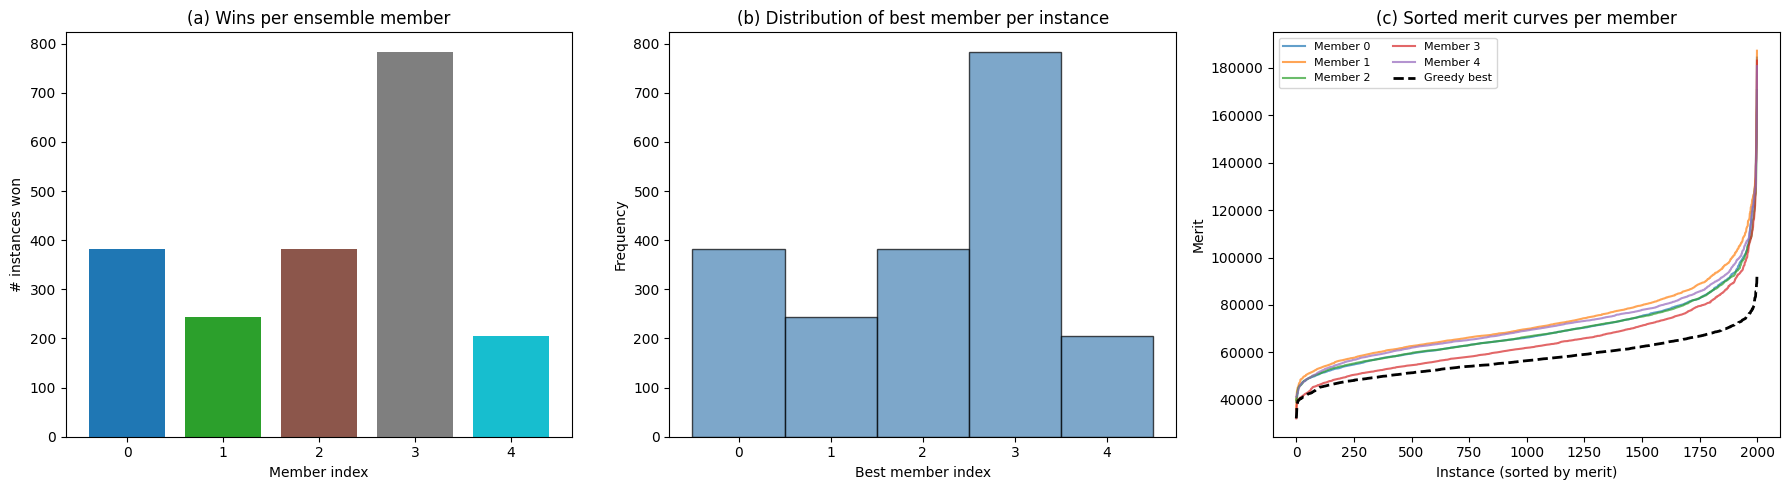

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) Bar chart: wins per member ---
ax = axes[0]
member_ids = list(range(n_members))
counts = [win_counts.get(i, 0) for i in member_ids]
colors = plt.cm.tab10(np.linspace(0, 1, n_members))
ax.bar(member_ids, counts, color=colors)
ax.set_xlabel('Member index')
ax.set_ylabel('# instances won')
ax.set_title('(a) Wins per ensemble member')
ax.set_xticks(member_ids)

# --- (b) Histogram of best-member index across instances ---
ax = axes[1]
ax.hist(best_member_per_instance, bins=np.arange(-0.5, n_members + 0.5, 1),
        edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Best member index')
ax.set_ylabel('Frequency')
ax.set_title('(b) Distribution of best member per instance')
ax.set_xticks(member_ids)

# --- (c) Sorted merit per member to show overlap ---
ax = axes[2]
for m_idx in range(n_members):
    sorted_m = np.sort(merits[m_idx])
    ax.plot(sorted_m, label=f'Member {m_idx}', alpha=0.7)
# Also show the greedy-best merit
greedy_best = merits.min(axis=0)
ax.plot(np.sort(greedy_best), 'k--', linewidth=2, label='Greedy best')
ax.set_xlabel('Instance (sorted by merit)')
ax.set_ylabel('Merit')
ax.set_title('(c) Sorted merit curves per member')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [99]:
# --- Improvement from ensemble over single-best-overall model ---
mean_merits_per_member = merits.mean(axis=1)  # (M,)
overall_best_member = mean_merits_per_member.argmin()
print(f"Overall best single member (by mean merit): Member {overall_best_member}")
print(f"  Mean merit: {mean_merits_per_member[overall_best_member]:.4e}")

greedy_merit_per_instance = merits.min(axis=0)  # (N,)
greedy_mean = greedy_merit_per_instance.mean()
single_mean = mean_merits_per_member[overall_best_member]

improvement_abs = single_mean - greedy_mean
improvement_pct = 100 * improvement_abs / single_mean

print(f"\nGreedy-ensemble mean merit: {greedy_mean:.4e}")
print(f"Single-best mean merit:     {single_mean:.4e}")
print(f"Improvement:  {improvement_abs:.4e}  ({improvement_pct:.2f}%)")

Overall best single member (by mean merit): Member 3
  Mean merit: 6.4302e+04

Greedy-ensemble mean merit: 5.7188e+04
Single-best mean merit:     6.4302e+04
Improvement:  7.1136e+03  (11.06%)


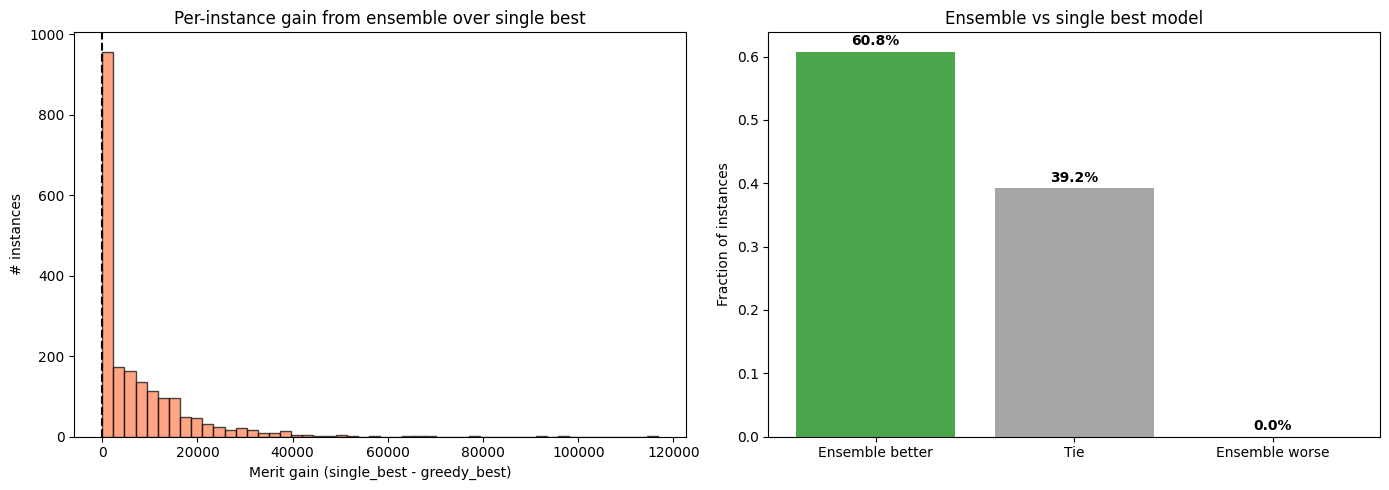

In [100]:
# --- Per-instance: how much does the greedy winner beat the single best model? ---
single_merits = merits[overall_best_member]  # (N,)
per_instance_gain = single_merits - greedy_merit_per_instance  # (N,)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(per_instance_gain, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel('Merit gain (single_best - greedy_best)')
ax.set_ylabel('# instances')
ax.set_title('Per-instance gain from ensemble over single best')

ax = axes[1]
frac_improved = (per_instance_gain > 0).mean()
frac_same = (per_instance_gain == 0).mean()
frac_worse = (per_instance_gain < 0).mean()
ax.bar(['Ensemble better', 'Tie', 'Ensemble worse'],
       [frac_improved, frac_same, frac_worse],
       color=['green', 'gray', 'red'], alpha=0.7)
ax.set_ylabel('Fraction of instances')
ax.set_title('Ensemble vs single best model')
for i, v in enumerate([frac_improved, frac_same, frac_worse]):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [101]:
# --- Summary table ---
print(f"{'Member':<10} {'Mean Merit':<14} {'Mean Obj':<14} {'Mean Eq Viol':<14} {'Mean Ineq Viol':<14} {'Wins':<8}")
print('-' * 74)
for m_idx in range(n_members):
    print(f"{m_idx:<10} {merits[m_idx].mean():<14.4e} {objs[m_idx].mean():<14.4e} "
          f"{eq_viols[m_idx].mean():<14.4e} {ineq_viols[m_idx].mean():<14.4e} {win_counts.get(m_idx, 0):<8}")
print('-' * 74)
print(f"{'Greedy':<10} {greedy_mean:<14.4e}")
print(f"{'Best-1':<10} {single_mean:<14.4e}  (Member {overall_best_member})")

Member     Mean Merit     Mean Obj       Mean Eq Viol   Mean Ineq Viol Wins    
--------------------------------------------------------------------------
0          6.8807e+04     2.7386e-01     6.6968e-01     1.8385e-02     383     
1          7.2703e+04     5.7783e-01     7.1139e-01     1.5637e-02     244     
2          6.8665e+04     6.0456e+00     6.6551e-01     2.1076e-02     383     
3          6.4302e+04     2.5117e-01     6.2854e-01     1.4474e-02     784     
4          7.1075e+04     -2.9569e+00    6.9598e-01     1.4806e-02     206     
--------------------------------------------------------------------------
Greedy     5.7188e+04    
Best-1     6.4302e+04      (Member 3)


In [102]:
# ── Deep-dive: how bad is Member 3 on the instances it loses? ──
import numpy as np

dominant = 3
loses_mask = best_member_per_instance != dominant  # instances where member 3 is NOT best
wins_mask = best_member_per_instance == dominant

n_loses = loses_mask.sum()
n_wins = wins_mask.sum()

print(f"Member {dominant} loses on {n_loses} / {len(best_member_per_instance)} instances\n")

# Merit of member 3 vs greedy-best on instances where member 3 loses
member3_merit_on_losses = merits[dominant][loses_mask]
greedy_merit_on_losses  = np.array([merits[best_member_per_instance[i]][i] 
                                     for i in np.where(loses_mask)[0]])

gap_on_losses = member3_merit_on_losses - greedy_merit_on_losses

print("On instances where Member 3 loses:")
print(f"  Member 3 mean merit:      {member3_merit_on_losses.mean():.4e}")
print(f"  Best-member mean merit:   {greedy_merit_on_losses.mean():.4e}")
print(f"  Mean gap (M3 - best):     {gap_on_losses.mean():.4e}")
print(f"  Max gap:                  {gap_on_losses.max():.4e}")
print(f"  Min gap:                  {gap_on_losses.min():.4e}")
print(f"  Median gap:               {np.median(gap_on_losses):.4e}")

print(f"\nOn instances where Member 3 wins:")
member3_merit_on_wins = merits[dominant][wins_mask]
second_best_on_wins = np.array([
    np.partition([merits[m][i] for m in range(len(merits)) if m != dominant], 0)[0]
    for i in np.where(wins_mask)[0]
])
margin_on_wins = second_best_on_wins - member3_merit_on_wins
print(f"  Member 3 mean merit:      {member3_merit_on_wins.mean():.4e}")
print(f"  2nd-best mean merit:      {second_best_on_wins.mean():.4e}")
print(f"  Mean margin (2nd - M3):   {margin_on_wins.mean():.4e}")

print(f"\n{'='*60}")
print(f"Contribution breakdown to overall mean merit improvement:")
total_improvement = merits[dominant].mean() - np.array([
    merits[best_member_per_instance[i]][i] for i in range(len(best_member_per_instance))
]).mean()
improvement_from_losses = (member3_merit_on_losses.sum() - greedy_merit_on_losses.sum()) / len(best_member_per_instance)
improvement_from_wins = 0.0  # no improvement on wins (member 3 IS the best)

print(f"  Total improvement:           {total_improvement:.4e}")
print(f"  From loss instances ({n_loses:4d}):  {improvement_from_losses:.4e}  ({improvement_from_losses/total_improvement*100:.1f}%)")
print(f"  From win instances  ({n_wins:4d}):  {improvement_from_wins:.4e}  ({improvement_from_wins/total_improvement*100:.1f}%)")

Member 3 loses on 1216 / 2000 instances

On instances where Member 3 loses:
  Member 3 mean merit:      7.0238e+04
  Best-member mean merit:   5.8538e+04
  Mean gap (M3 - best):     1.1700e+04
  Max gap:                  1.1678e+05
  Min gap:                  9.3381e+00
  Median gap:               8.8078e+03

On instances where Member 3 wins:
  Member 3 mean merit:      5.5095e+04
  2nd-best mean merit:      6.1985e+04
  Mean margin (2nd - M3):   6.8904e+03

Contribution breakdown to overall mean merit improvement:
  Total improvement:           7.1136e+03
  From loss instances (1216):  7.1136e+03  (100.0%)
  From win instances  ( 784):  0.0000e+00  (0.0%)


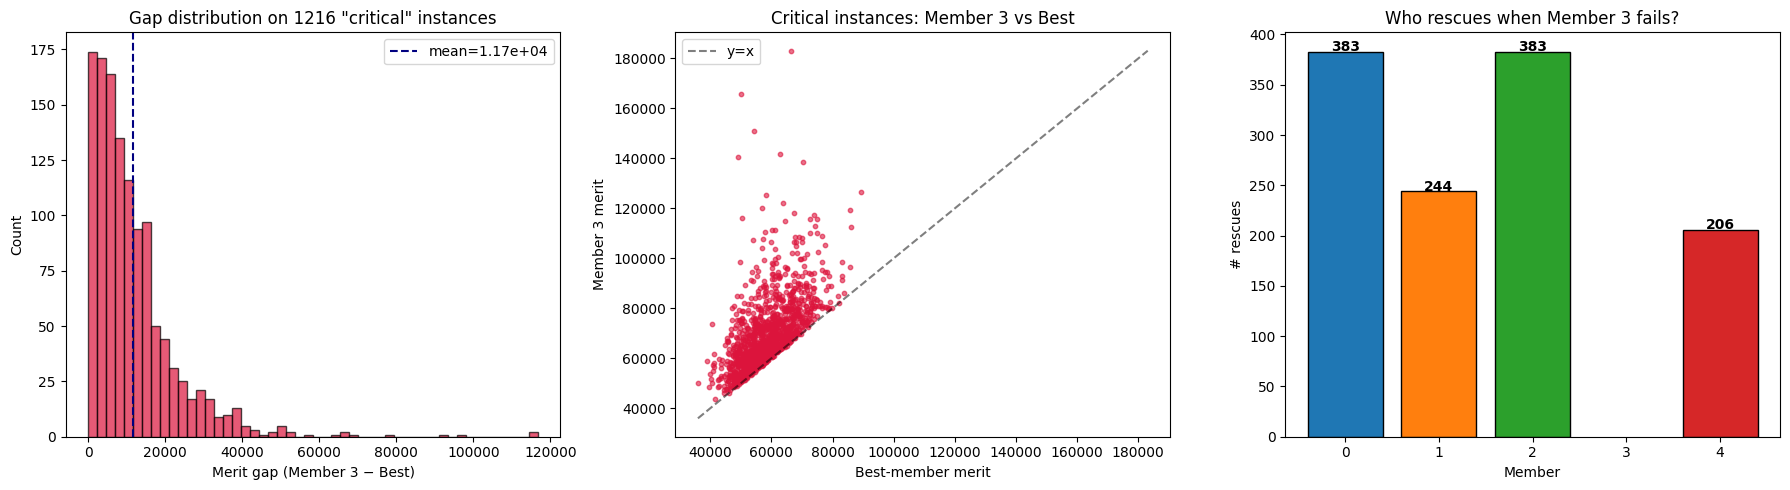


Rescue breakdown:
  Member 0: rescues 383 instances (31.5%)
  Member 1: rescues 244 instances (20.1%)
  Member 2: rescues 383 instances (31.5%)
  Member 4: rescues 206 instances (16.9%)


In [103]:
# Add as another new cell — visualize the "critical" instances

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Histogram of gaps on loss instances
axes[0].hist(gap_on_losses, bins=50, edgecolor='k', alpha=0.7, color='crimson')
axes[0].set_xlabel('Merit gap (Member 3 − Best)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Gap distribution on {n_loses} "critical" instances')
axes[0].axvline(gap_on_losses.mean(), color='navy', ls='--', label=f'mean={gap_on_losses.mean():.2e}')
axes[0].legend()

# 2) Scatter: member 3 merit vs best-member merit on loss instances
axes[1].scatter(greedy_merit_on_losses, member3_merit_on_losses, s=10, alpha=0.6, c='crimson')
lims = [min(greedy_merit_on_losses.min(), member3_merit_on_losses.min()),
        max(greedy_merit_on_losses.max(), member3_merit_on_losses.max())]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='y=x')
axes[1].set_xlabel('Best-member merit')
axes[1].set_ylabel('Member 3 merit')
axes[1].set_title('Critical instances: Member 3 vs Best')
axes[1].legend()

# 3) Which members rescue these instances?
rescue_members = best_member_per_instance[loses_mask]
unique, counts = np.unique(rescue_members, return_counts=True)
axes[2].bar(unique, counts, color=['C0','C1','C2','C3','C4'], edgecolor='k')
axes[2].set_xlabel('Member')
axes[2].set_ylabel('# rescues')
axes[2].set_title('Who rescues when Member 3 fails?')
for u, c in zip(unique, counts):
    axes[2].text(u, c + 0.5, str(c), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('critical_instances_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRescue breakdown:")
for u, c in zip(unique, counts):
    print(f"  Member {u}: rescues {c} instances ({c/n_loses*100:.1f}%)")

In [104]:
# ── What's special about instances where Member 3 fails? ──

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

dominant = 3
loses_mask = best_member_per_instance != dominant
wins_mask = best_member_per_instance == dominant

# Get the raw input features (X) for all test instances
X_all = []
Y_all = []
for X_batch, Y_batch in test_loader:
    X_all.append(X_batch.numpy())
    Y_all.append(Y_batch.numpy())
X_all = np.concatenate(X_all, axis=0)  # (N, d_in)
Y_all = np.concatenate(Y_all, axis=0)  # (N, d_out)

X_fail = X_all[loses_mask]
X_win  = X_all[wins_mask]
Y_fail = Y_all[loses_mask]
Y_win  = Y_all[wins_mask]

n_fail = X_fail.shape[0]
n_win  = X_win.shape[0]
d_in   = X_all.shape[1]

print(f"Feature dim: {d_in}")
print(f"Fail instances: {n_fail},  Win instances: {n_win}\n")

# ── 1. Basic feature statistics: mean, std, norms ──
print("="*70)
print("Feature-level comparison (mean ± std)")
print(f"{'Statistic':<30} {'Fail instances':<22} {'Win instances':<22} {'p-value':<12}")
print("-"*86)

# Norms
fail_norms = np.linalg.norm(X_fail, axis=1)
win_norms  = np.linalg.norm(X_win, axis=1)
_, p_norm = stats.mannwhitneyu(fail_norms, win_norms, alternative='two-sided')
print(f"{'||x||_2 (input norm)':<30} {fail_norms.mean():.4f} ± {fail_norms.std():.4f}    "
      f"{win_norms.mean():.4f} ± {win_norms.std():.4f}    {p_norm:.2e}")

# Per-feature mean
fail_feat_mean = X_fail.mean(axis=1)
win_feat_mean  = X_win.mean(axis=1)
_, p_fmean = stats.mannwhitneyu(fail_feat_mean, win_feat_mean, alternative='two-sided')
print(f"{'mean(x_i) per instance':<30} {fail_feat_mean.mean():.4f} ± {fail_feat_mean.std():.4f}    "
      f"{win_feat_mean.mean():.4f} ± {win_feat_mean.std():.4f}    {p_fmean:.2e}")

# Per-feature std (spread within each instance)
fail_feat_std = X_fail.std(axis=1)
win_feat_std  = X_win.std(axis=1)
_, p_fstd = stats.mannwhitneyu(fail_feat_std, win_feat_std, alternative='two-sided')
print(f"{'std(x_i) per instance':<30} {fail_feat_std.mean():.4f} ± {fail_feat_std.std():.4f}    "
      f"{win_feat_std.mean():.4f} ± {win_feat_std.std():.4f}    {p_fstd:.2e}")

# Min / Max feature
fail_feat_min = X_fail.min(axis=1)
win_feat_min  = X_win.min(axis=1)
_, p_fmin = stats.mannwhitneyu(fail_feat_min, win_feat_min, alternative='two-sided')
print(f"{'min(x_i) per instance':<30} {fail_feat_min.mean():.4f} ± {fail_feat_min.std():.4f}    "
      f"{win_feat_min.mean():.4f} ± {win_feat_min.std():.4f}    {p_fmin:.2e}")

fail_feat_max = X_fail.max(axis=1)
win_feat_max  = X_win.max(axis=1)
_, p_fmax = stats.mannwhitneyu(fail_feat_max, win_feat_max, alternative='two-sided')
print(f"{'max(x_i) per instance':<30} {fail_feat_max.mean():.4f} ± {fail_feat_max.std():.4f}    "
      f"{win_feat_max.mean():.4f} ± {win_feat_max.std():.4f}    {p_fmax:.2e}")

# Solution norms
fail_sol_norms = np.linalg.norm(Y_fail, axis=1)
win_sol_norms  = np.linalg.norm(Y_win, axis=1)
_, p_snorm = stats.mannwhitneyu(fail_sol_norms, win_sol_norms, alternative='two-sided')
print(f"{'||y*||_2 (solution norm)':<30} {fail_sol_norms.mean():.4f} ± {fail_sol_norms.std():.4f}    "
      f"{win_sol_norms.mean():.4f} ± {win_sol_norms.std():.4f}    {p_snorm:.2e}")

print("-"*86)
print("(p < 0.05 → statistically significant difference)\n")

Feature dim: 50
Fail instances: 1216,  Win instances: 784

Feature-level comparison (mean ± std)
Statistic                      Fail instances         Win instances          p-value     
--------------------------------------------------------------------------------------
||x||_2 (input norm)           4.0844 ± 0.2569    4.0531 ± 0.2587    7.51e-03
mean(x_i) per instance         -0.0109 ± 0.0780    0.0148 ± 0.0790    5.45e-11
std(x_i) per instance          0.5722 ± 0.0365    0.5675 ± 0.0376    5.65e-03
min(x_i) per instance          -0.9609 ± 0.0396    -0.9577 ± 0.0420    1.09e-01
max(x_i) per instance          0.9578 ± 0.0413    0.9634 ± 0.0369    1.13e-02
||y*||_2 (solution norm)       12.8198 ± 0.5136    12.7982 ± 0.5094    3.39e-01
--------------------------------------------------------------------------------------
(p < 0.05 → statistically significant difference)



In [105]:
# ── 2. Per-feature importance: which features differ most between fail/win? ──

# Mann-Whitney U test per feature
p_values = []
effect_sizes = []  # rank-biserial correlation
for j in range(d_in):
    stat, p = stats.mannwhitneyu(X_fail[:, j], X_win[:, j], alternative='two-sided')
    # rank-biserial effect size
    r = 1 - (2 * stat) / (n_fail * n_win)
    p_values.append(p)
    effect_sizes.append(r)

p_values = np.array(p_values)
effect_sizes = np.array(effect_sizes)

# Top features by effect size
top_k = min(20, d_in)
top_idx = np.argsort(np.abs(effect_sizes))[::-1][:top_k]

print(f"Top {top_k} most discriminative features (by |effect size|):")
print(f"{'Feature':<10} {'Effect size':<14} {'p-value':<12} {'Fail mean':<14} {'Win mean':<14}")
print("-"*64)
for idx in top_idx:
    print(f"{idx:<10} {effect_sizes[idx]:<14.4f} {p_values[idx]:<12.2e} "
          f"{X_fail[:, idx].mean():<14.4f} {X_win[:, idx].mean():<14.4f}")

n_significant = (p_values < 0.05).sum()
n_significant_bonf = (p_values < 0.05 / d_in).sum()
print(f"\nSignificant features (p < 0.05): {n_significant} / {d_in}")
print(f"Significant features (Bonferroni p < {0.05/d_in:.2e}): {n_significant_bonf} / {d_in}")

Top 20 most discriminative features (by |effect size|):
Feature    Effect size    p-value      Fail mean      Win mean      
----------------------------------------------------------------
6          0.2182         1.58e-16     -0.0717        0.1455        
21         0.1986         6.00e-14     -0.0831        0.1152        
33         -0.1887        9.81e-13     0.0704         -0.1194       
2          0.1865         1.79e-12     -0.0921        0.0948        
36         0.1526         7.89e-09     -0.0479        0.1030        
49         -0.1243        2.62e-06     0.0373         -0.0884       
16         -0.1221        3.92e-06     0.0568         -0.0644       
23         0.1209         4.87e-06     -0.0210        0.1004        
43         0.1192         6.55e-06     -0.0545        0.0644        
10         0.1164         1.09e-05     -0.0429        0.0727        
0          -0.1028        1.02e-04     0.0249         -0.0789       
37         0.0964         2.69e-04     -0.0611     

In [106]:
# ── 4. Top-10 worst failures: examine individual instances ──

# Rank fail instances by gap (M3 merit - best merit)
fail_indices = np.where(loses_mask)[0]
gap_sorted_idx = np.argsort(gap_on_losses)[::-1]  # largest gap first

print("Top 10 instances where Member 3 fails the worst:")
print(f"{'Rank':<6} {'Inst idx':<10} {'M3 merit':<14} {'Best merit':<14} {'Gap':<14} "
      f"{'Best member':<12} {'||x||₂':<10} {'||y*||₂':<10}")
print("-"*90)

worst_10_indices = []
for rank, loc in enumerate(gap_sorted_idx[:10]):
    i = fail_indices[loc]
    m3_m = merits[dominant][i]
    best_m = merits[best_member_per_instance[i]][i]
    gap = m3_m - best_m
    bm = best_member_per_instance[i]
    xn = np.linalg.norm(X_all[i])
    yn = np.linalg.norm(Y_all[i])
    worst_10_indices.append(i)
    print(f"{rank+1:<6} {i:<10} {m3_m:<14.4e} {best_m:<14.4e} {gap:<14.4e} "
          f"{bm:<12} {xn:<10.4f} {yn:<10.4f}")

print("\nBreakdown of all member merits on top-5 worst instances:")
for rank, i in enumerate(worst_10_indices[:5]):
    print(f"\n  Instance {i} (rank {rank+1}):")
    for m_idx in range(n_members):
        marker = " *** BEST" if m_idx == best_member_per_instance[i] else ""
        marker2 = " (dominant)" if m_idx == dominant else ""
        print(f"    Member {m_idx}: merit={merits[m_idx][i]:.4e}  "
              f"obj={objs[m_idx][i]:.4e}  eq_viol={eq_viols[m_idx][i]:.4e}  "
              f"ineq_viol={ineq_viols[m_idx][i]:.4e}{marker}{marker2}")

Top 10 instances where Member 3 fails the worst:
Rank   Inst idx   M3 merit       Best merit     Gap            Best member  ||x||₂     ||y*||₂   
------------------------------------------------------------------------------------------
1      1853       1.8309e+05     6.6312e+04     1.1678e+05     0            4.4236     12.6259   
2      91         1.6571e+05     5.0047e+04     1.1567e+05     2            3.9144     12.6341   
3      1669       1.5078e+05     5.4257e+04     9.6519e+04     2            4.0603     12.7619   
4      1009       1.4050e+05     4.9201e+04     9.1297e+04     0            4.1141     12.8218   
5      656        1.4189e+05     6.2741e+04     7.9154e+04     0            3.9388     12.5546   
6      1657       1.3856e+05     7.0240e+04     6.8321e+04     0            4.2439     13.1268   
7      1955       1.2521e+05     5.8275e+04     6.6940e+04     0            4.2229     13.1222   
8      977        1.1612e+05     5.0435e+04     6.5688e+04     1            